In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
melb = pd.read_pickle("/content/drive/MyDrive/melbourne_csv/melb_cleaned.pkl")
print(f"Loaded {melb.shape[0]:,} rows, {melb.shape[1]} columns")
melb.head()

Loaded 1,113,151 rows, 16 columns


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime,Rain Category
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00,No Rain
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00,No Rain
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00,No Rain
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00,No Rain
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00,No Rain


In [17]:
melb.describe()

,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
count,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113143e+06,1.113140e+06,1.113117e+06,1.112596e+06,1113151
mean,6.449869e+00,1.576466e+01,1.143807e+01,2.611543e+01,1.577788e+01,1.205041e+01,9.006135e+00,6.695214e+01,1.932511e+01,2.260400e+01,1.017328e+03,7.823287e-01,2016-12-30 11:54:40.273780480
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,-9.999000e+03,-9.600000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.881000e+02,0.000000e+00,2011-01-01 00:04:00
25%,3.000000e+00,8.000000e+00,5.000000e+00,1.000000e+01,1.180000e+01,7.600000e+00,6.000000e+00,5.500000e+01,1.100000e+01,1.300000e+01,1.012300e+03,0.000000e+00,2014-02-06 13:40:00
50%,6.000000e+00,1.600000e+01,1.100000e+01,3.000000e+01,1.510000e+01,1.170000e+01,8.500000e+00,6.800000e+01,1.700000e+01,2.000000e+01,1.017400e+03,0.000000e+00,2016-10-17 13:50:00
75%,9.000000e+00,2.300000e+01,1.700000e+01,4.000000e+01,1.890000e+01,1.650000e+01,1.160000e+01,8.000000e+01,2.600000e+01,3.000000e+01,1.022600e+03,2.000000e-01,2019-10-13 06:35:00
max,1.200000e+01,3.100000e+01,2.300000e+01,5.900000e+01,4.350000e+01,4.330000e+01,3.690000e+01,1.000000e+02,1.000000e+02,1.090000e+02,1.041900e+03,5.460000e+01,2025-03-12 16:30:00
std,3.442491e+00,8.809506e+00,6.886329e+00,1.724355e+01,5.615222e+00,1.517278e+01,4.062210e+00,1.766679e+01,1.059140e+01,1.272109e+01,7.636249e+00,2.955180e+00,NaN


In [18]:
melb.dtypes

,0
Year,object
Month,int32
Day,int64
Hour,int64
Minute,int64
Air Temp (degrees C),float64
Apparent Temp (degrees C),float64
Dew Pt Temp (degrees C),float64
Humidity (%),int64
Wind Direction,object


## Modelling

In [19]:
# Make sure Datetime is the index and is sorted
melb_ts = melb.copy()
melb_ts = melb_ts.dropna(subset=["Datetime"])
melb_ts = melb_ts.sort_values("Datetime").reset_index(drop=True)
melb_ts = melb_ts.set_index("Datetime")

print(f"Date range: {melb_ts.index.min()} to {melb_ts.index.max()}")

Date range: 2011-01-01 00:04:00 to 2025-03-12 16:30:00


In [20]:
# Build daily aggregates
# For most variables used multiple aggregations
agg_dict = {
    "Air Temp (degrees C)":      ["min", "max", "mean"],
    "Apparent Temp (degrees C)": ["min", "max", "mean"],
    "Dew Pt Temp (degrees C)":   ["mean"],
    "Humidity (%)":              ["mean", "max", "min"],
    "Wind Speed (km/h)":         ["mean", "max"],
    "Wind Gust  (km/h)":         ["max"],
    "MSLP (hPa)":                ["mean", "min", "max"],
    "Rainfall since 9 am (mm)":  ["max"],
}

daily = melb_ts.resample("D").agg(agg_dict)

# Flatten the multi-index columns into readable single-level names
daily.columns = ["_".join(col).strip() for col in daily.columns]
daily = daily.rename(columns={"Rainfall since 9 am (mm)_max": "rainfall_mm"})

# Add wind direction as the daily mode (most frequent direction)
def safe_mode(series):
    series = series.dropna()
    if len(series) == 0:
        return np.nan
    m = series.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

daily["wind_dir_mode"] = melb_ts["Wind Direction"].resample("D").agg(safe_mode)

print(f"Daily dataset: {daily.shape[0]:,} days, {daily.shape[1]} columns")
daily.head()

# 14 years × 365 days ≈ 5,110 days, plus some leap days, gives ~5,185. ✓

Daily dataset: 5,185 days, 18 columns


,Air Temp (degrees C)_min,Air Temp (degrees C)_max,Air Temp (degrees C)_mean,Apparent Temp (degrees C)_min,Apparent Temp (degrees C)_max,Apparent Temp (degrees C)_mean,Dew Pt Temp (degrees C)_mean,Humidity (%)_mean,Humidity (%)_max,Humidity (%)_min,Wind Speed (km/h)_mean,Wind Speed (km/h)_max,Wind Gust (km/h)_max,MSLP (hPa)_mean,MSLP (hPa)_min,MSLP (hPa)_max,rainfall_mm,wind_dir_mode
Datetime,,,,,,,,,,,,,,,,,,
2011-01-01,16.8,24.9,19.650787,0.0,0.0,0.0,11.987008,61.574803,80.0,47.0,14.350394,37.0,43.0,1011.803543,1007.2,1015.2,0.0,S
2011-01-02,15.3,21.4,18.175258,0.0,0.0,0.0,8.078351,52.097938,71.0,40.0,21.891753,33.0,39.0,1016.319072,1013.9,1017.6,0.0,S
2011-01-03,14.1,20.3,16.590734,0.0,0.0,0.0,5.467954,47.814672,57.0,38.0,24.389961,35.0,41.0,1016.943629,1015.6,1018.5,0.0,S
2011-01-04,12.9,21.5,16.800775,0.0,0.0,0.0,8.856589,59.879845,85.0,44.0,15.709302,30.0,37.0,1012.389922,1009.7,1016.3,0.0,SSE
2011-01-05,14.6,21.3,18.117188,0.0,0.0,0.0,11.730078,66.585938,79.0,52.0,19.898438,32.0,37.0,1010.092578,1008.2,1012.4,0.0,S


In [21]:
# Quick sanity check on the rainfall
print(f"Days with rain: {(daily['rainfall_mm'] > 0).sum():,} ({(daily['rainfall_mm'] > 0).mean()*100:.1f}%)")
print(f"Mean rainfall: {daily['rainfall_mm'].mean():.2f} mm")
print(f"Max daily rainfall: {daily['rainfall_mm'].max():.1f} mm")
print(f"Missing rainfall values: {daily['rainfall_mm'].isna().sum()}")

Days with rain: 2,677 (51.6%)
Mean rainfall: 2.32 mm
Max daily rainfall: 54.6 mm
Missing rainfall values: 2


In [40]:
# about half of Melbourne days have some rain. This matches what Bureau of Meteorology says about Melbourne's climate.
# 2.32 mm — average daily rain across all days (rainy and dry)
# 54.6 mm — biggest single day in the dataset of rain fall
# 2 — out of 5,185 days, only 2 have missing rainfall. prollly some error too tiny  tho

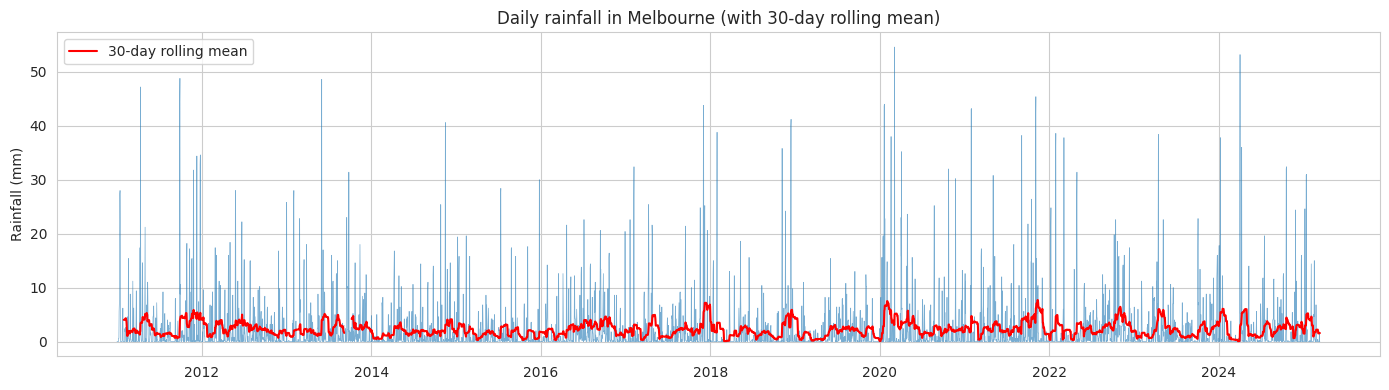

In [22]:
# Visualize the daily rainfall over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily["rainfall_mm"], linewidth=0.5, alpha=0.6)
ax.plot(daily.index, daily["rainfall_mm"].rolling(30).mean(),
        color="red", linewidth=1.5, label="30-day rolling mean")
ax.set_title("Daily rainfall in Melbourne (with 30-day rolling mean)")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# red rolling-mean line shows daily rainfall over time,
# the red line is the 30-day average, which smooths out the noise to see seasonal/yearly patterns.

#### Feature Engineering

In [23]:
# Start with a working copy
df = daily.copy()

# (a) Lag features — past values of key variables
LAG_DAYS = [1, 2, 3, 7]
LAG_VARS = ["rainfall_mm", "Humidity (%)_mean", "MSLP (hPa)_mean",
            "Air Temp (degrees C)_mean", "Wind Speed (km/h)_mean"]

for var in LAG_VARS:
    for lag in LAG_DAYS:
        df[f"{var}_lag{lag}"] = df[var].shift(lag)

print(f"After adding lags: {df.shape[1]} columns")

# e.g : rainfall_mm_lag1 (yesterday's rainfall), Humidity_mean_lag7 (humidity a week ago)

After adding lags: 38 columns


In [24]:
# (b) Rolling statistics — recent trends
ROLL_WINDOWS = [3, 7]
ROLL_VARS = ["rainfall_mm", "Humidity (%)_mean", "MSLP (hPa)_mean",
             "Air Temp (degrees C)_mean"]

for var in ROLL_VARS:
    for w in ROLL_WINDOWS:
        # We shift by 1 first so today's value isn't included in the rolling
        # window — otherwise we'd be leaking the target into the features
        df[f"{var}_roll{w}_mean"] = df[var].shift(1).rolling(w).mean()
        df[f"{var}_roll{w}_std"]  = df[var].shift(1).rolling(w).std()

print(f"After adding rolling stats: {df.shape[1]} columns")

# e.g: rainfall_mm_roll7_mean = average rainfall over the past 7 days

After adding rolling stats: 54 columns


In [25]:
# (c) Pressure trend — change in MSLP over the last 24 hours
# A falling barometer is the classic signal of incoming rain
df["MSLP_change_1d"] = df["MSLP (hPa)_mean"].diff(1)
df["MSLP_change_3d"] = df["MSLP (hPa)_mean"].diff(3)

# Same for humidity trend
df["Humidity_change_1d"] = df["Humidity (%)_mean"].diff(1)

In [26]:
# (d) Cyclical encoding for month and day-of-year
df["month"]       = df.index.month
df["day_of_year"] = df.index.dayofyear

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["doy_sin"]   = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["doy_cos"]   = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

# We don't need the raw month / day_of_year anymore as features
# (we'll drop them when building the feature matrix)

In [27]:
# (e) Wind direction — one-hot encode the 16 compass directions
#keep STILL as its own category
wind_dummies = pd.get_dummies(df["wind_dir_mode"], prefix="wind", dummy_na=False)
df = pd.concat([df, wind_dummies], axis=1)

print(f"Wind direction categories: {list(wind_dummies.columns)}")
print(f"After all feature engineering: {df.shape[1]} columns")

Wind direction categories: ['wind_E', 'wind_ENE', 'wind_ESE', 'wind_N', 'wind_NE', 'wind_NNE', 'wind_NNW', 'wind_NW', 'wind_S', 'wind_SE', 'wind_SSE', 'wind_SSW', 'wind_STILL', 'wind_SW', 'wind_W', 'wind_WNW', 'wind_WSW']
After all feature engineering: 80 columns


#### Define Targets

In [28]:
# Regression target: tomorrow's rainfall in mm
df["target_rain_mm"] = df["rainfall_mm"].shift(-1)

# Log-transformed regression target (handles the right-skewed distribution)
df["target_rain_log"] = np.log1p(df["target_rain_mm"])

# Classification target: will it rain tomorrow?
df["target_rain_yn"] = (df["target_rain_mm"] > 0).astype(int)
# Note: rows where tomorrow's rainfall is NaN will produce target_rain_yn=0 incorrectly
# Fix this by setting those to NaN
df.loc[df["target_rain_mm"].isna(), "target_rain_yn"] = np.nan

print("Target distribution (regression):")
print(df["target_rain_mm"].describe())
print()
print("Target distribution (classification):")
print(df["target_rain_yn"].value_counts(dropna=False))

Target distribution (regression):
count    5182.000000
mean        2.316364
std         5.313351
min         0.000000
25%         0.000000
50%         0.200000
75%         2.200000
max        54.600000
Name: target_rain_mm, dtype: float64

Target distribution (classification):
target_rain_yn
1.0    2677
0.0    2505
NaN       3
Name: count, dtype: int64


In [ ]:
# 5182 — three rows dropped (2 missing rainfall + 1 last row that can't have "tomorrow" data)
# The classification target shows 2,677 rainy days, 2,505 dry days, 3 NaN. Nicely balanced (roughly 52/48 split).

#### Time-Based Split

In [29]:
# Drop columns we shouldn't feed to the model:
# - the categorical wind_dir_mode (already one-hot encoded)
# - the raw month / day_of_year (we use cyclical versions)
# - the three target columns
DROP_COLS = ["wind_dir_mode", "month", "day_of_year",
             "target_rain_mm", "target_rain_log", "target_rain_yn"]

feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f"Number of features: {len(feature_cols)}")

# Drop rows with NaN in target or in any feature
# (early rows have NaN from lags; the very last row has NaN from the target shift)
model_df = df.dropna(subset=feature_cols + ["target_rain_mm"]).copy()
print(f"Modelling rows after dropping NaN: {model_df.shape[0]:,} (from {df.shape[0]:,} total daily rows)")

Number of features: 77
Modelling rows after dropping NaN: 5,167 (from 5,185 total daily rows)


In [ ]:
# 77 features after dropping the helper columns and the three target columns. 5,167 modelling rows after dropping rows with any NaN.

In [30]:
# Time-based split
n = len(model_df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train = model_df.iloc[:train_end]
val   = model_df.iloc[train_end:val_end]
test  = model_df.iloc[val_end:]

print(f"Train:      {train.shape[0]:,} days  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Validation: {val.shape[0]:,} days  ({val.index.min().date()} -> {val.index.max().date()})")
print(f"Test:       {test.shape[0]:,} days  ({test.index.min().date()} -> {test.index.max().date()})")

Train:      3,616 days  (2011-01-08 -> 2020-12-11)
Validation: 775 days  (2020-12-12 -> 2023-01-25)
Test:       776 days  (2023-01-26 -> 2025-03-11)


In [31]:
# Build X / y matrices for each split
X_train, y_train_reg, y_train_log, y_train_clf = (
    train[feature_cols], train["target_rain_mm"],
    train["target_rain_log"], train["target_rain_yn"]
)
X_val, y_val_reg, y_val_log, y_val_clf = (
    val[feature_cols], val["target_rain_mm"],
    val["target_rain_log"], val["target_rain_yn"]
)
X_test, y_test_reg, y_test_log, y_test_clf = (
    test[feature_cols], test["target_rain_mm"],
    test["target_rain_log"], test["target_rain_yn"]
)

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

Feature matrix shapes:
  X_train: (3616, 77)
  X_val:   (775, 77)
  X_test:  (776, 77)


#### Baseline Models



In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label:25s}  MAE={mae:5.2f}  RMSE={rmse:5.2f}  R2={r2:+.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

[]


In [36]:
# Baseline 1: Persistence — predict yesterday's rainfall
# (we use the lag-1 feature we already engineered)
y_pred_persist = X_test["rainfall_mm_lag1"]
results.append(evaluate(y_test_reg, y_pred_persist, "Persistence (yesterday)"))

Persistence (yesterday)    MAE= 3.64  RMSE= 7.56  R2=-0.975


In [37]:
# Baseline 2: Climatology — predict the monthly mean from training data
monthly_climatology = train.groupby(train.index.month)["target_rain_mm"].mean()
y_pred_climate = test.index.month.map(monthly_climatology)
results.append(evaluate(y_test_reg, y_pred_climate, "Climatology (monthly avg)"))

Climatology (monthly avg)  MAE= 3.02  RMSE= 5.36  R2=+0.010


In [38]:
# Baseline 3: Zero — always predict no rain
# (a sanity check; if you can't beat this you have a serious problem)
y_pred_zero = np.zeros(len(y_test_reg))
results.append(evaluate(y_test_reg, y_pred_zero, "Always predict 0 mm"))

Always predict 0 mm        MAE= 2.32  RMSE= 5.86  R2=-0.186


In [39]:
# Summary table
baseline_results = pd.DataFrame(results)
print()
print("Baseline summary (test set):")
print(baseline_results.to_string(index=False))


Baseline summary (test set):
                    model      MAE     RMSE        R2
  Persistence (yesterday) 3.637887 7.564857 -0.975229
Climatology (monthly avg) 3.018269 5.355071  0.010202
      Always predict 0 mm 2.322680 5.862356 -0.186207


### XGBoost Modelling

In [44]:
import pickle
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)

In [48]:
### RECAP ###
splits = {
    "X_train": X_train, "X_val": X_val, "X_test": X_test,
    "y_train_reg": y_train_reg, "y_val_reg": y_val_reg, "y_test_reg": y_test_reg,
    "y_train_log": y_train_log, "y_val_log": y_val_log, "y_test_log": y_test_log,
    "y_train_clf": y_train_clf, "y_val_clf": y_val_clf, "y_test_clf": y_test_clf,
    "feature_cols": feature_cols,
    "baseline_results": baseline_results
}
# Unpack everything (redundant after directly creating splits, but kept for clarity)
X_train, X_val, X_test = splits["X_train"], splits["X_val"], splits["X_test"]
y_train_reg, y_val_reg, y_test_reg = splits["y_train_reg"], splits["y_val_reg"], splits["y_test_reg"]
y_train_log, y_val_log, y_test_log = splits["y_train_log"], splits["y_val_log"], splits["y_test_log"]
y_train_clf, y_val_clf, y_test_clf = splits["y_train_clf"], splits["y_val_clf"], splits["y_test_clf"]
feature_cols = splits["feature_cols"]
baseline_results = splits["baseline_results"]

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Number of features: {len(feature_cols)}")
print()
print("Baselines to beat:")
print(baseline_results.to_string(index=False))

X_train: (3616, 77)
X_val:   (775, 77)
X_test:  (776, 77)
Number of features: 77

Baselines to beat:
                    model      MAE     RMSE        R2
  Persistence (yesterday) 3.637887 7.564857 -0.975229
Climatology (monthly avg) 3.018269 5.355071  0.010202
      Always predict 0 mm 2.322680 5.862356 -0.186207


In [49]:
# Install / check XGBoost, Optuna, SHAP
import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

# Optuna and SHAP — install if missing (Colab usually has these but versions vary)
try:
    import optuna
    print(f"Optuna version: {optuna.__version__}")
except ImportError:
    !pip install optuna --quiet
    import optuna
    print(f"Installed Optuna {optuna.__version__}")

try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    !pip install shap --quiet
    import shap
    print(f"Installed SHAP {shap.__version__}")

XGBoost version: 3.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.6 MB/s eta 0:00:00
Installed Optuna 4.8.0
SHAP version: 0.51.0


In [50]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# The same evaluator we used for baselines, so results are comparable
def evaluate_reg(y_true, y_pred, label):
    # Clip negative predictions to 0 — rainfall cannot be negative
    y_pred = np.clip(y_pred, 0, None)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label:35s}  MAE={mae:5.2f}  RMSE={rmse:5.2f}  R2={r2:+.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

# collect all model results here for the final comparison
xgb_results = []

#### Vanilla XGBoost Regressor (Baseline)

In [51]:
# Vanilla XGBoost: predict rainfall_mm directly
model_vanilla = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42,
    n_jobs=-1,
)

model_vanilla.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=200,
)

print(f"\nBest iteration: {model_vanilla.best_iteration}")
print(f"Best validation MAE: {model_vanilla.best_score:.3f}")

[0]	validation_0-mae:3.22190
[142]	validation_0-mae:2.34425

Best iteration: 92
Best validation MAE: 2.337


In [52]:
y_pred_vanilla = model_vanilla.predict(X_test)
xgb_results.append(evaluate_reg(y_test_reg, y_pred_vanilla, "XGB vanilla (direct target)"))

XGB vanilla (direct target)          MAE= 2.04  RMSE= 4.16  R2=+0.401


#### Log-Target XGBoost Regressor (log(1+rainfall))

In [53]:
model_log = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42,
    n_jobs=-1,
)

model_log.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=200,
)

print(f"\nBest iteration: {model_log.best_iteration}")
print(f"Best validation MAE (log scale): {model_log.best_score:.3f}")


[0]	validation_0-mae:0.74298
[162]	validation_0-mae:0.48036

Best iteration: 112
Best validation MAE (log scale): 0.478


In [54]:
y_pred_log_scale = model_log.predict(X_test)
y_pred_log = np.expm1(y_pred_log_scale)
y_pred_log = np.clip(y_pred_log, 0, None)

xgb_results.append(evaluate_reg(y_test_reg, y_pred_log, "XGB log-target"))

XGB log-target                       MAE= 1.82  RMSE= 4.62  R2=+0.263


#### XGBoost Classifier

In [55]:
# Some target rows have NaN (the 3 missing-rainfall days). Drop those for classification.
clf_mask_train = ~y_train_clf.isna()
clf_mask_val   = ~y_val_clf.isna()
clf_mask_test  = ~y_test_clf.isna()

X_train_clf = X_train[clf_mask_train]
y_train_clf_clean = y_train_clf[clf_mask_train].astype(int)
X_val_clf = X_val[clf_mask_val]
y_val_clf_clean = y_val_clf[clf_mask_val].astype(int)
X_test_clf = X_test[clf_mask_test]
y_test_clf_clean = y_test_clf[clf_mask_test].astype(int)

print(f"Classification training rows: {len(y_train_clf_clean)}")
print(f"Class balance (train): {y_train_clf_clean.value_counts().to_dict()}")

Classification training rows: 3616
Class balance (train): {1: 1876, 0: 1740}


In [56]:
# XGBoost classifier
model_clf = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

model_clf.fit(
    X_train_clf, y_train_clf_clean,
    eval_set=[(X_val_clf, y_val_clf_clean)],
    verbose=200,
)

print(f"\nBest iteration: {model_clf.best_iteration}")

[0]	validation_0-logloss:0.67480
[200]	validation_0-logloss:0.43727
[240]	validation_0-logloss:0.44084

Best iteration: 190


In [57]:
# Evaluate the classifier
y_pred_clf       = model_clf.predict(X_test_clf)           # hard prediction (0 or 1)
y_pred_clf_proba = model_clf.predict_proba(X_test_clf)[:, 1]  # probability of rain

acc    = accuracy_score(y_test_clf_clean, y_pred_clf)
f1     = f1_score(y_test_clf_clean, y_pred_clf)
rocauc = roc_auc_score(y_test_clf_clean, y_pred_clf_proba)
prauc  = average_precision_score(y_test_clf_clean, y_pred_clf_proba)

print(f"Classification metrics on test set:")
print(f"  Accuracy:  {acc:.3f}   (baseline: predict majority class = {y_test_clf_clean.value_counts(normalize=True).max():.3f})")
print(f"  F1 score:  {f1:.3f}")
print(f"  ROC-AUC:   {rocauc:.3f}   (0.5 = random, 1.0 = perfect)")
print(f"  PR-AUC:    {prauc:.3f}")
print()
print("Confusion matrix:")
cm = confusion_matrix(y_test_clf_clean, y_pred_clf)
print(pd.DataFrame(cm,
                   index=["actual: no rain", "actual: rain"],
                   columns=["pred: no rain", "pred: rain"]))

Classification metrics on test set:
  Accuracy:  0.785   (baseline: predict majority class = 0.512)
  F1 score:  0.773
  ROC-AUC:   0.856   (0.5 = random, 1.0 = perfect)
  PR-AUC:    0.865

Confusion matrix:
                 pred: no rain  pred: rain
actual: no rain            325          72
actual: rain                95         284


#### Visualizations

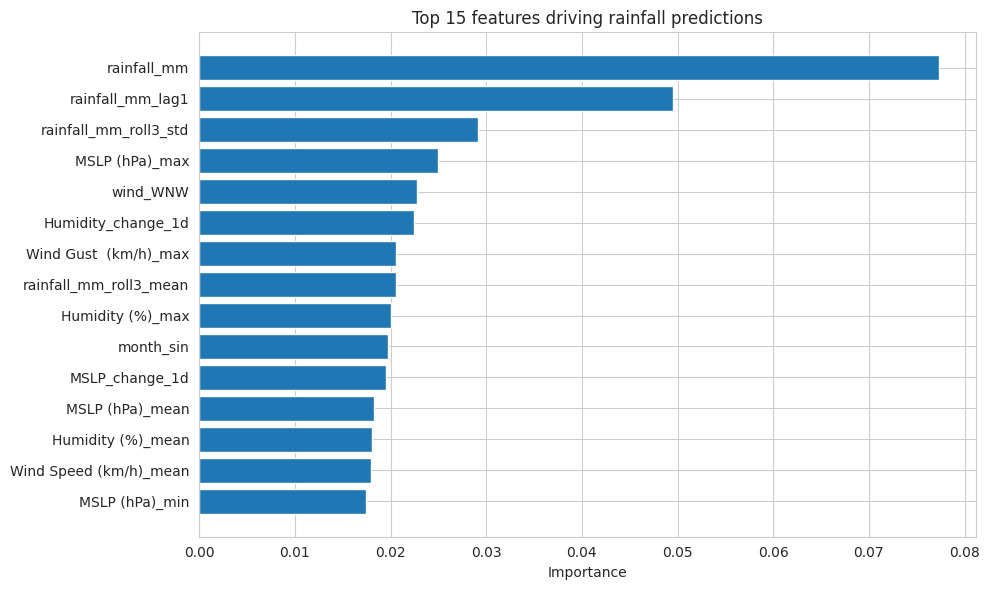

Top 5 most important features:
              feature  importance
          rainfall_mm    0.077370
     rainfall_mm_lag1    0.049509
rainfall_mm_roll3_std    0.029108
       MSLP (hPa)_max    0.024953
             wind_WNW    0.022763


In [58]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_vanilla.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 features driving rainfall predictions')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importance_df.head().to_string(index=False))

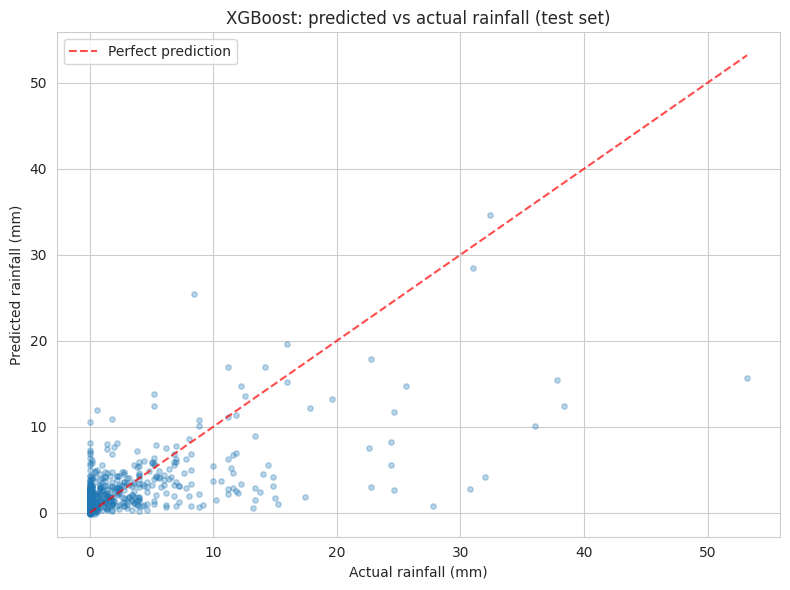

In [59]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_vanilla, alpha=0.3, s=15)
max_val = max(y_test_reg.max(), y_pred_vanilla.max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='Perfect prediction')
plt.xlabel('Actual rainfall (mm)')
plt.ylabel('Predicted rainfall (mm)')
plt.title('XGBoost: predicted vs actual rainfall (test set)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Dots above the line = over-predicted, below = under-predicted and dot on the line means the model nailed it
# under-prediction problem at the high end : reason -> The model consistently under-predicts the biggest storms coz Storm days are rare (~2% of the dataset).

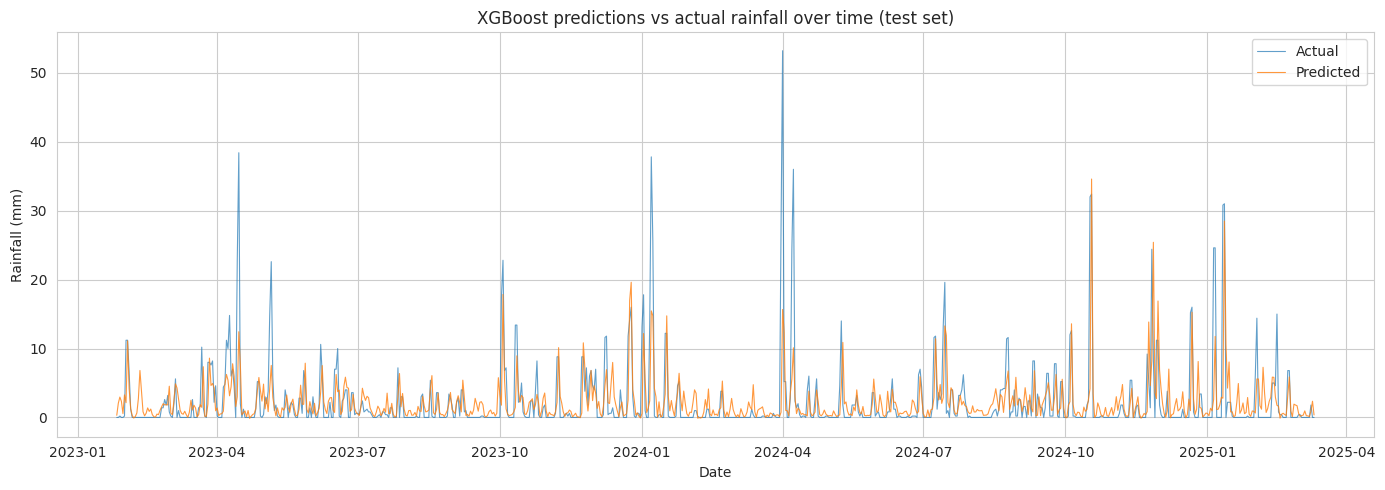

In [60]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(X_test.index, y_test_reg.values, label='Actual', alpha=0.7, linewidth=0.8)
ax.plot(X_test.index, y_pred_vanilla, label='Predicted', alpha=0.8, linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
ax.set_title('XGBoost predictions vs actual rainfall over time (test set)')
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
xgb_df = pd.DataFrame(xgb_results)
all_results = pd.concat([baseline_results, xgb_df], ignore_index=True)
all_results = all_results.sort_values("MAE").reset_index(drop=True)

print("FINAL RESULTS (sorted by MAE, lower is better):")
print("=" * 70)
print(all_results.to_string(index=False))
print()
best = all_results.iloc[0]
print(f"Best model: {best['model']} (MAE = {best['MAE']:.2f})")
print(f"Improvement over best baseline (2.32): {(2.32 - best['MAE'])/2.32*100:.1f}%")

FINAL RESULTS (sorted by MAE, lower is better):
                      model      MAE     RMSE        R2
             XGB log-target 1.817756 4.622056  0.262628
XGB vanilla (direct target) 2.039454 4.164885  0.401282
        Always predict 0 mm 2.322680 5.862356 -0.186207
  Climatology (monthly avg) 3.018269 5.355071  0.010202
    Persistence (yesterday) 3.637887 7.564857 -0.975229

Best model: XGB log-target (MAE = 1.82)
Improvement over best baseline (2.32): 21.6%


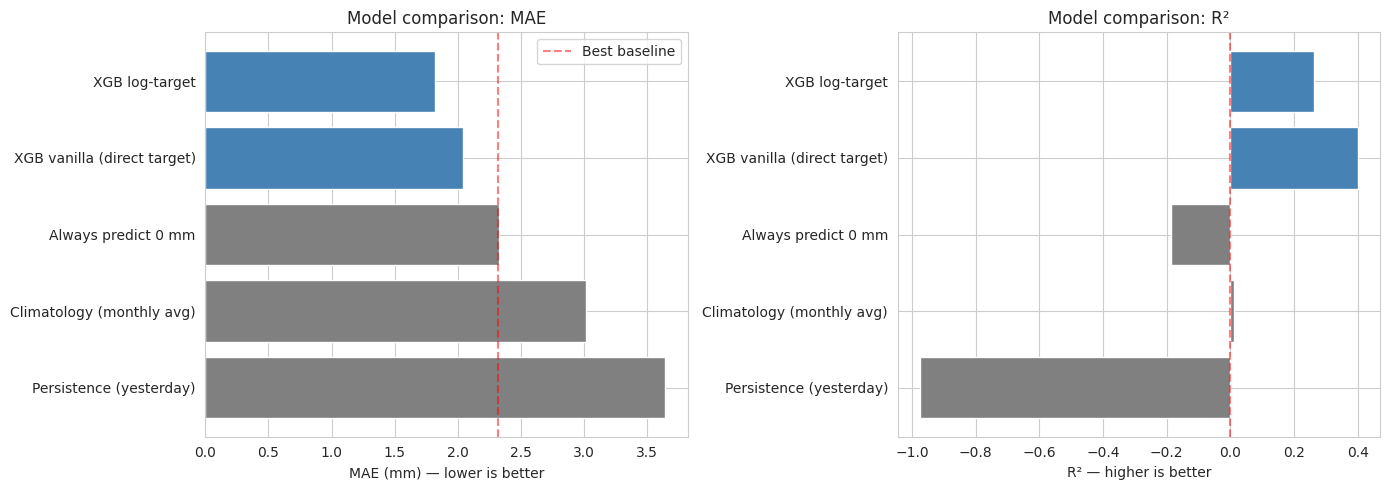

In [62]:
#same info as in the table above,
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

is_baseline = all_results['model'].str.contains('Persistence|Climatology|Always', case=False)
colors = ['gray' if b else 'steelblue' for b in is_baseline]

axes[0].barh(all_results['model'], all_results['MAE'], color=colors)
axes[0].set_xlabel('MAE (mm) — lower is better')
axes[0].set_title('Model comparison: MAE')
axes[0].invert_yaxis()
axes[0].axvline(2.32, color='red', linestyle='--', alpha=0.5, label='Best baseline')
axes[0].legend()

axes[1].barh(all_results['model'], all_results['R2'], color=colors)
axes[1].set_xlabel('R² — higher is better')
axes[1].set_title('Model comparison: R²')
axes[1].invert_yaxis()
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()